In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import RocCurveDisplay, roc_auc_score


In [31]:
df = pd.read_csv('/content/HeartDiseaseTrain-Test.csv')

In [32]:
df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [33]:
df.shape

(1025, 14)

In [34]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate',
       'exercise_induced_angina', 'oldpeak', 'slope',
       'vessels_colored_by_flourosopy', 'thalassemia', 'target'],
      dtype='object')

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

In [35]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_blood_pressure,0
cholestoral,0
fasting_blood_sugar,0
rest_ecg,0
Max_heart_rate,0
exercise_induced_angina,0
oldpeak,0


In [36]:
# Categorical columns convert to numerical
df_encoded = pd.get_dummies(df, drop_first=True)

In [37]:
df_encoded.head()

,age,resting_blood_pressure,cholestoral,Max_heart_rate,oldpeak,target,sex_Male,chest_pain_type_Atypical angina,chest_pain_type_Non-anginal pain,chest_pain_type_Typical angina,...,exercise_induced_angina_Yes,slope_Flat,slope_Upsloping,vessels_colored_by_flourosopy_One,vessels_colored_by_flourosopy_Three,vessels_colored_by_flourosopy_Two,vessels_colored_by_flourosopy_Zero,thalassemia_No,thalassemia_Normal,thalassemia_Reversable Defect
0,52,125,212,168,1.0,0,True,False,False,True,...,False,False,False,False,False,True,False,False,False,True
1,53,140,203,155,3.1,0,True,False,False,True,...,True,False,True,False,False,False,True,False,False,True
2,70,145,174,125,2.6,0,True,False,False,True,...,True,False,True,False,False,False,True,False,False,True
3,61,148,203,161,0.0,0,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
4,62,138,294,106,1.9,0,False,False,False,True,...,False,True,False,False,True,False,False,False,False,False


In [38]:
df_encoded.shape

(1025, 23)

In [39]:
# sprate the feature
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [41]:
# scale the all numerical value
scaler = StandardScaler()

In [45]:
continuous_cols = [
    "age",
    "resting_blood_pressure",
    "cholestoral",
    "Max_heart_rate",
    "oldpeak",
]

In [46]:
#copy
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

/tmp/ipykernel_2124/2418419841.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="Set2")


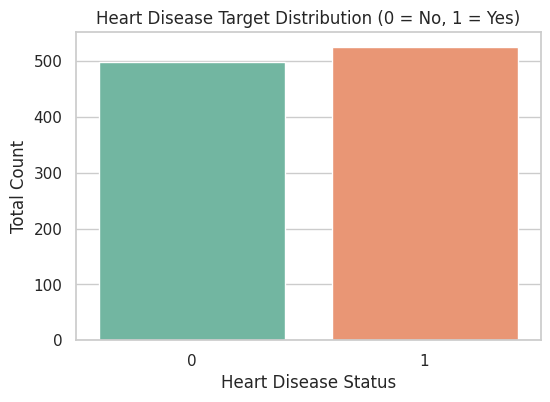

In [47]:
#count lot

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df, palette="Set2")
plt.title("Heart Disease Target Distribution (0 = No, 1 = Yes)")
plt.xlabel("Heart Disease Status")
plt.ylabel("Total Count")
plt.show()

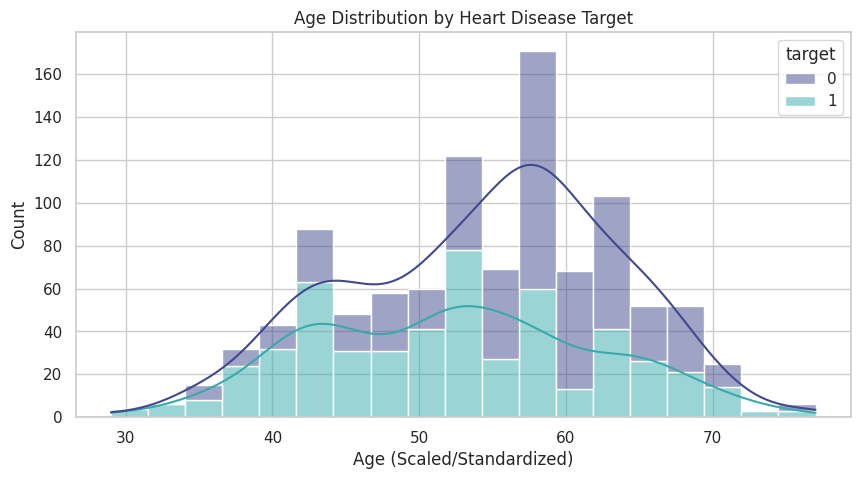

In [48]:
#histplot
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df, x="age", hue="target", multiple="stack", kde=True, palette="mako"
)
plt.title("Age Distribution by Heart Disease Target")
plt.xlabel("Age (Scaled/Standardized)")
plt.ylabel("Count")
plt.show()

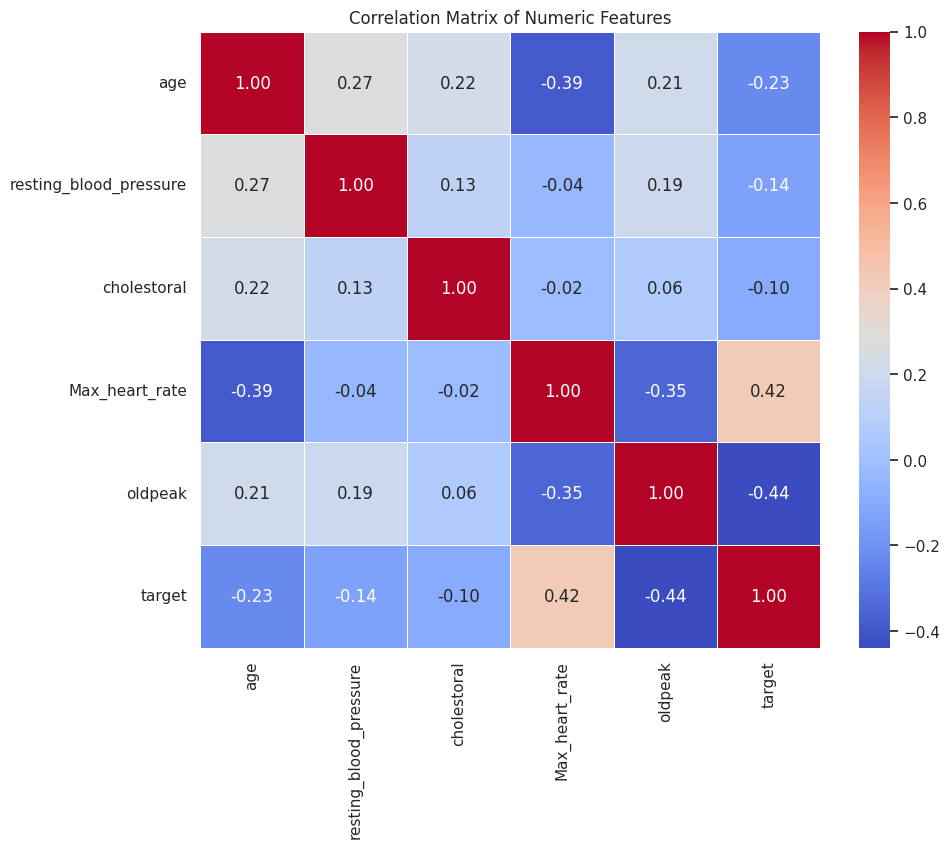

In [49]:
#heatmap

plt.figure(figsize=(10, 8))
numeric_cols = [
    "age",
    "resting_blood_pressure",
    "cholestoral",
    "Max_heart_rate",
    "oldpeak",
    "target",
]

sns.heatmap(
    df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

In [50]:
# train the modle
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [53]:
y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

In [55]:
print(accuracy)

0.8682926829268293


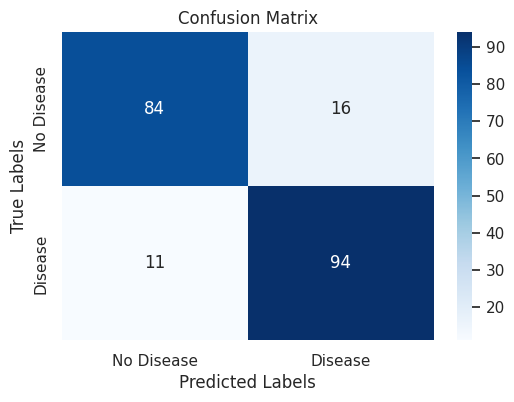

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Confusion Matrix generate karna
cm = confusion_matrix(y_test, y_pred)

# 2. Matrix ko plot karna
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"],
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

0.9431428571428571


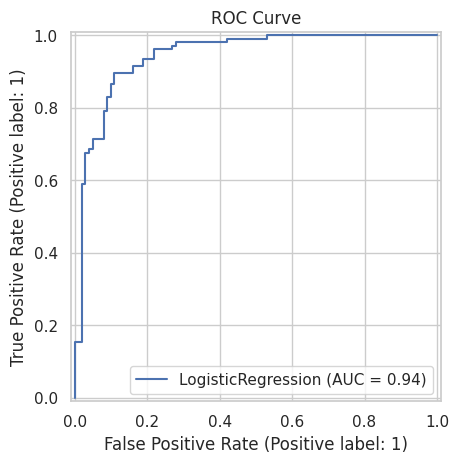

In [60]:
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

# 2. ROC AUC Score
auc_score = roc_auc_score(y_test, y_pred_prob)
print(auc_score)

# courve plot
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.title("ROC Curve")
plt.show()

In [74]:
# Features  weights and dataframe
feature_importance = pd.DataFrame(
    {"Feature": X.columns, "Importance": model.coef_[0]}
)

In [72]:
feature_importance = feature_importance.sort_values(
    by="Importance", ascending=False, key=abs
)

In [73]:
# Final Result display
print("--- Important Features Affecting Prediction ---")
print(feature_importance.to_string(index=False))

--- Important Features Affecting Prediction ---
                                 Feature  Importance
       vessels_colored_by_flourosopy_Two   -1.878617
          chest_pain_type_Typical angina   -1.762249
                                sex_Male   -1.506170
           thalassemia_Reversable Defect   -1.241080
                              slope_Flat   -1.115851
      vessels_colored_by_flourosopy_Zero    1.039482
       vessels_colored_by_flourosopy_One   -0.918738
             exercise_induced_angina_Yes   -0.805014
         chest_pain_type_Atypical angina   -0.783164
     vessels_colored_by_flourosopy_Three   -0.765395
                          thalassemia_No   -0.750116
                         slope_Upsloping   -0.526109
                                 oldpeak   -0.476408
                  resting_blood_pressure   -0.381285
                          Max_heart_rate    0.346083
          rest_ecg_ST-T wave abnormality    0.330582
                             cholestoral   -0.26626